In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
"D:\Users\Admin\Projects\dso\SAR_ML\data\DSO\mstar\npy_noscaling_files\real\2s1\2s1_real_elevDeg_15_azCenter_0_sn_b01.npy"

In [3]:
arr = np.load("/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/2s1/2s1_real_elevDeg_15_azCenter_0_sn_b01.npy")

In [56]:
def dso_np_file_loader(path):
    arr = np.load(path)
    complex_arr = arr[:, :, 0] + 1j * arr[:, :, 1]
    # complex_arr[complex_arr < 1e-17] = 0
    return complex_arr

In [15]:
real_test = dso_np_file_loader("/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/2s1/2s1_real_elevDeg_15_azCenter_0_sn_b01.npy")

In [31]:
np.abs(real_test)

array([[0.06270671, 0.09226845, 0.03851984, ..., 0.00716648, 0.07256063,
        0.08151874],
       [0.07076901, 0.12810086, 0.09226845, ..., 0.05195699, 0.08958102,
        0.09316426],
       [0.09764332, 0.09316426, 0.03045755, ..., 0.06449833, 0.13705896,
        0.16124584],
       ...,
       [0.01881201, 0.04837375, 0.03404079, ..., 0.01612458, 0.03941565,
        0.05106118],
       [0.03583241, 0.05106118, 0.0170204 , ..., 0.03583241, 0.02866593,
        0.01343715],
       [0.04210308, 0.02149945, 0.02149945, ..., 0.06001928, 0.02956174,
        0.03314498]], shape=(128, 128))

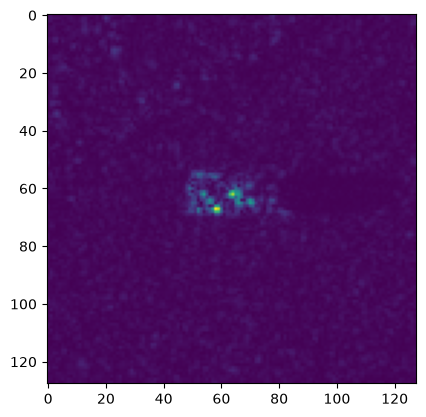

In [19]:
plt.imshow(np.abs(real_test))
plt.show()

In [22]:
synth_test = dso_np_file_loader("/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/synth/2s1/2s1_synth_elevDeg_15_azCenter_0.npy")

In [49]:
np.abs(synth_test)

array([[2.39895044e-18, 9.90844530e-18, 6.20936508e-18, ...,
        2.95953434e-17, 9.30268209e-18, 1.44376084e-17],
       [1.78903625e-18, 1.37283287e-17, 4.90653893e-18, ...,
        2.36624485e-17, 5.07841964e-18, 1.36071692e-17],
       [2.38154577e-18, 7.02726957e-18, 7.75791923e-18, ...,
        2.11971923e-17, 8.84011307e-18, 5.94336649e-18],
       ...,
       [8.10345933e-18, 6.77778129e-18, 7.15244812e-18, ...,
        2.71050543e-18, 9.30284004e-18, 1.05522243e-17],
       [8.09547706e-18, 1.14096826e-17, 9.67069442e-18, ...,
        1.72657281e-17, 4.75197290e-18, 1.43987804e-17],
       [6.20652478e-18, 6.42155291e-18, 9.35434656e-18, ...,
        1.71564503e-17, 6.87955967e-18, 1.03915278e-17]], shape=(128, 128))

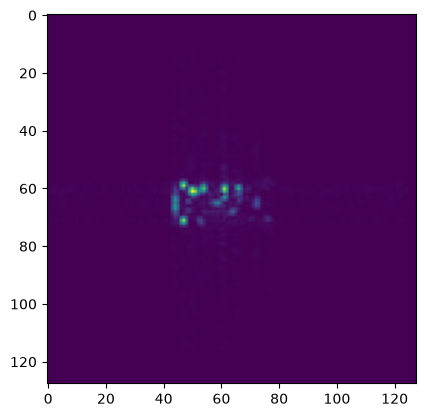

In [24]:
plt.imshow(np.abs(synth_test))
plt.show()

In [87]:
20*np.log10(1 + np.abs(synth_test) / (1 + np.abs(synth_test).max()))

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(128, 128))

In [1]:
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py

# Meas Image

In [35]:
meas_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real",
    extensions = (".npy"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = dso_np_file_loader
)

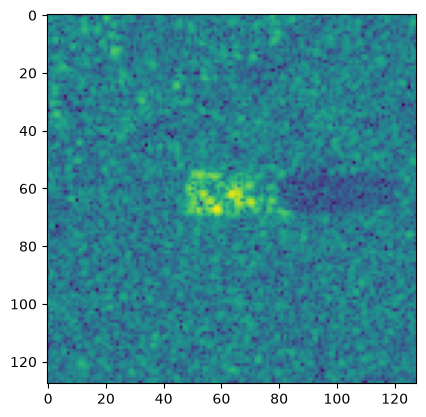

In [117]:
plt.imshow(meas_ds[0][0][0])

# Synth Image

In [88]:
no_aug_synth_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/synth",
    extensions = (".npy"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = dso_np_file_loader
)

In [89]:
len(no_aug_synth_ds)

5400

In [90]:
no_aug_synth_ds[0][0][0]

tensor([[2.8926e-16, 1.1570e-15, 7.0707e-16,  ..., 3.4068e-15, 1.0606e-15,
         1.6713e-15],
        [1.9284e-16, 1.5748e-15, 5.7851e-16,  ..., 2.7319e-15, 5.7851e-16,
         1.5748e-15],
        [2.8926e-16, 8.0349e-16, 8.9991e-16,  ..., 2.4426e-15, 1.0285e-15,
         6.7493e-16],
        ...,
        [9.3205e-16, 7.7135e-16, 8.3563e-16,  ..., 3.2140e-16, 1.0606e-15,
         1.2213e-15],
        [9.3205e-16, 1.3177e-15, 1.1249e-15,  ..., 1.9927e-15, 5.4637e-16,
         1.6713e-15],
        [7.0707e-16, 7.3921e-16, 1.0927e-15,  ..., 1.9927e-15, 8.0349e-16,
         1.1892e-15]])

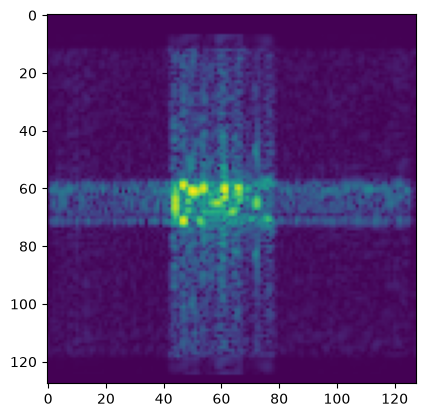

In [101]:
plt.imshow(no_aug_synth_ds[0][0][0])

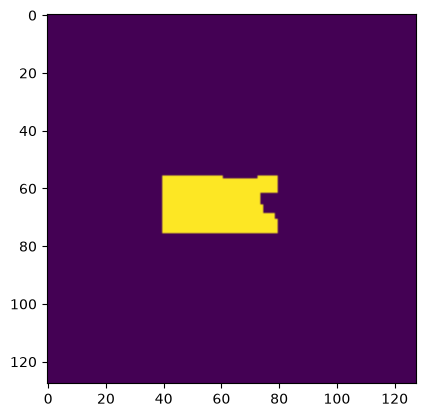

In [100]:
plt.imshow(np.load("/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/masks/npy_files/synth/2s1/2s1_synth_elevDeg_15_azCenter_0.npy"))

In [103]:
np.load("/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/masks/npy_files/synth/2s1/2s1_synth_elevDeg_15_azCenter_0.npy").shape

(128, 128)

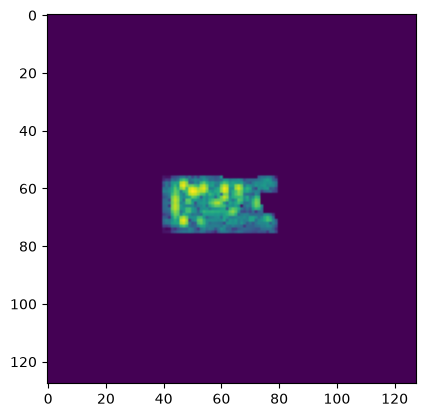

In [105]:
plt.imshow(no_aug_synth_ds[0][0][0].numpy() * np.load("/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/masks/npy_files/synth/2s1/2s1_synth_elevDeg_15_azCenter_0.npy"))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/mnt/c/Users/Admin/Downloads/MSTAR_sim_jul26.zip/MSTAR_sim_jul26/readsim_gtif")

In [3]:
from sim_chip import SimChip

In [4]:
sim_chip = SimChip.from_sim_tiff("/mnt/c/Users/Admin/Downloads/MSTAR_sim_jul26.zip/MSTAR_sim_jul26/ZSU234_X3230gz15sqp00/ZSU234_asp074g_X3230gz15sqp00_dispimg_fdf6d9968.tif")

In [5]:
sim_chip.slant_bdd_mask

array([[ 0,  0,  0, ..., 97, 97,  0],
       [97, 97, 97, ..., 97, 97,  0],
       [97, 97, 97, ..., 97, 97,  0],
       ...,
       [97, 97, 97, ..., 97, 97,  0],
       [97, 97, 97, ..., 97, 97,  0],
       [ 0,  0,  0, ..., 97, 97,  0]], shape=(158, 158), dtype=uint8)

In [6]:
unique_vals, counts = np.unique(sim_chip.slant_bdd_mask, return_counts=True)
for v, c in zip(unique_vals, counts):
    print(f'{v:3d} = {v:08b}   count={c}')

  0 = 00000000   count=316
 65 = 01000001   count=1619
 67 = 01000011   count=118
 97 = 01100001   count=22393
 99 = 01100011   count=16
193 = 11000001   count=26
195 = 11000011   count=244
225 = 11100001   count=86
227 = 11100011   count=146


In [7]:
unique_vals, counts = np.unique(sim_chip.ground_bdd_mask, return_counts=True)
for v, c in zip(unique_vals, counts):
    print(f'{v:3d} = {v:08b}   count={c}')

 65 = 01000001   count=1619
 67 = 01000011   count=118
 97 = 01100001   count=22709
 99 = 01100011   count=16
193 = 11000001   count=26
195 = 11000011   count=244
225 = 11100001   count=86
227 = 11100011   count=146


In [8]:
LogMapping()(Magnitude()(sim_chip.slant_img[0]))

array([[0.01033296, 0.0165748 , 0.00882867, ..., 0.01677245, 0.00639698,
        0.00653813],
       [0.01634281, 0.00793466, 0.00932851, ..., 0.01073849, 0.01820431,
        0.01153564],
       [0.00496335, 0.00117828, 0.0087224 , ..., 0.01305876, 0.00834122,
        0.00406304],
       ...,
       [0.01877897, 0.01267143, 0.01026424, ..., 0.01699126, 0.0059518 ,
        0.01150757],
       [0.00653386, 0.00851957, 0.00875156, ..., 0.02666469, 0.01399356,
        0.00629591],
       [0.00756152, 0.0176484 , 0.0009527 , ..., 0.01928454, 0.01132381,
        0.00728467]], shape=(158, 158), dtype=float32)

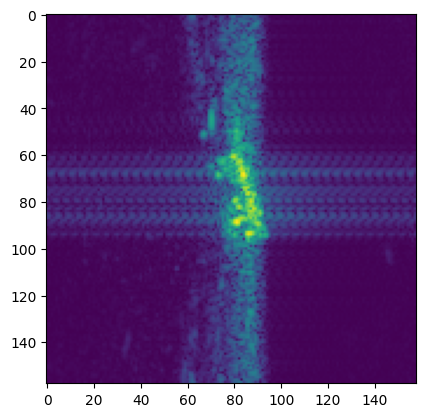

In [9]:
plt.imshow(LogMapping()(Magnitude()(sim_chip.slant_img[0])))

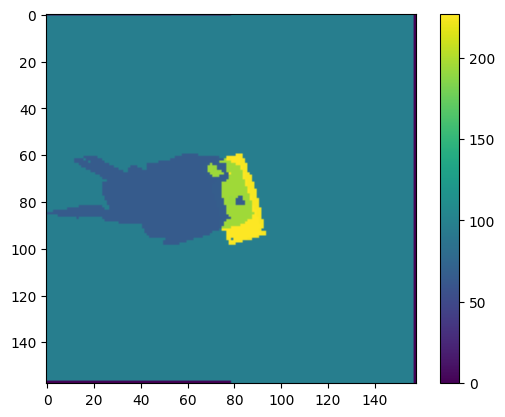

In [10]:
plt.imshow(sim_chip.slant_bdd_mask)
plt.colorbar()

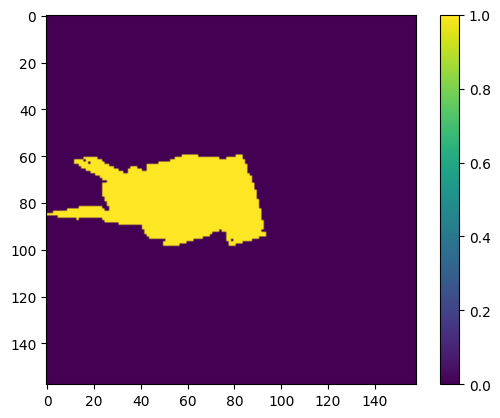

In [11]:
plt.imshow( (sim_chip.slant_bdd_mask != 0) & (sim_chip.slant_bdd_mask != 97) & (sim_chip.slant_bdd_mask != 99))
plt.colorbar()

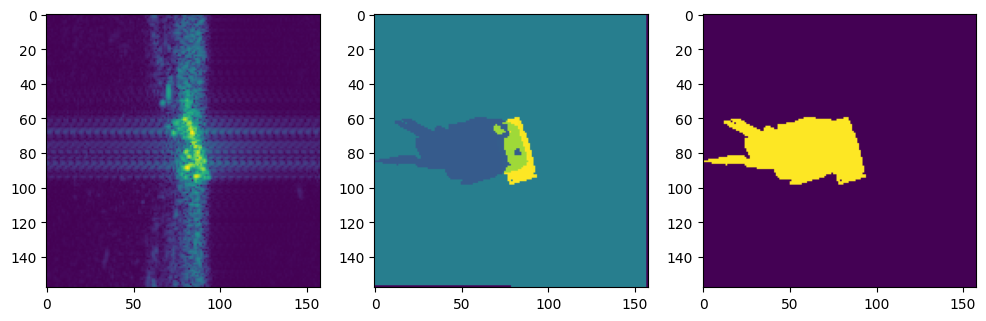

In [16]:
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(1, 3, 1)
ax1 = plt.imshow(LogMapping()(Magnitude()(sim_chip.slant_img[0])))

ax2 = fig.add_subplot(1, 3, 2)
ax2 = plt.imshow(sim_chip.slant_bdd_mask)

ax3 = fig.add_subplot(1, 3, 3)
ax3 = plt.imshow( (sim_chip.slant_bdd_mask != 0) & (sim_chip.slant_bdd_mask != 97) & (sim_chip.slant_bdd_mask != 99))

plt.show()